
Repetition 0
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.31720543
Mask difference: 0.06636461


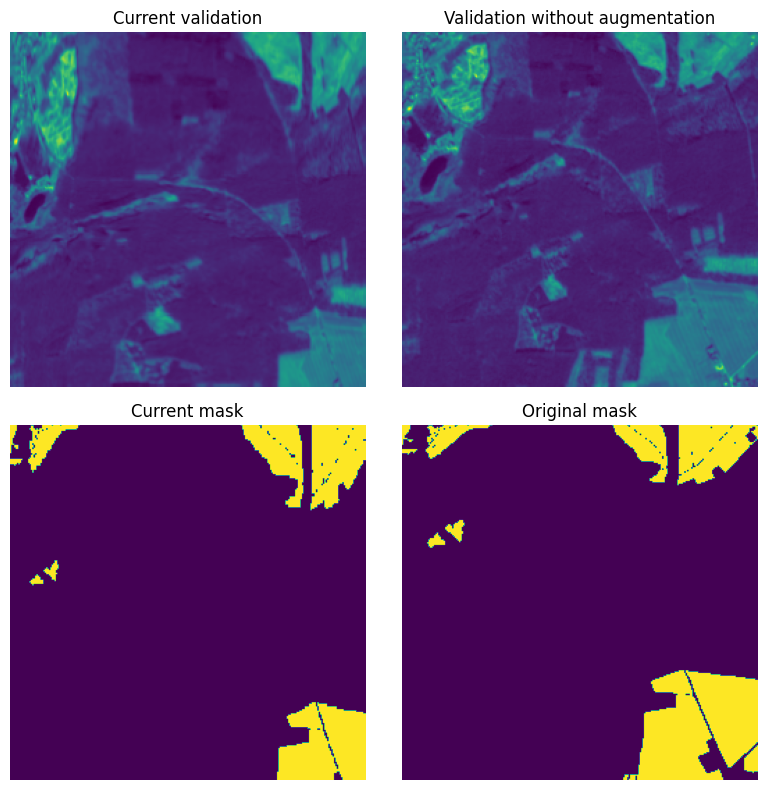


Repetition 1
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.5155373
Mask difference: 0.1255091


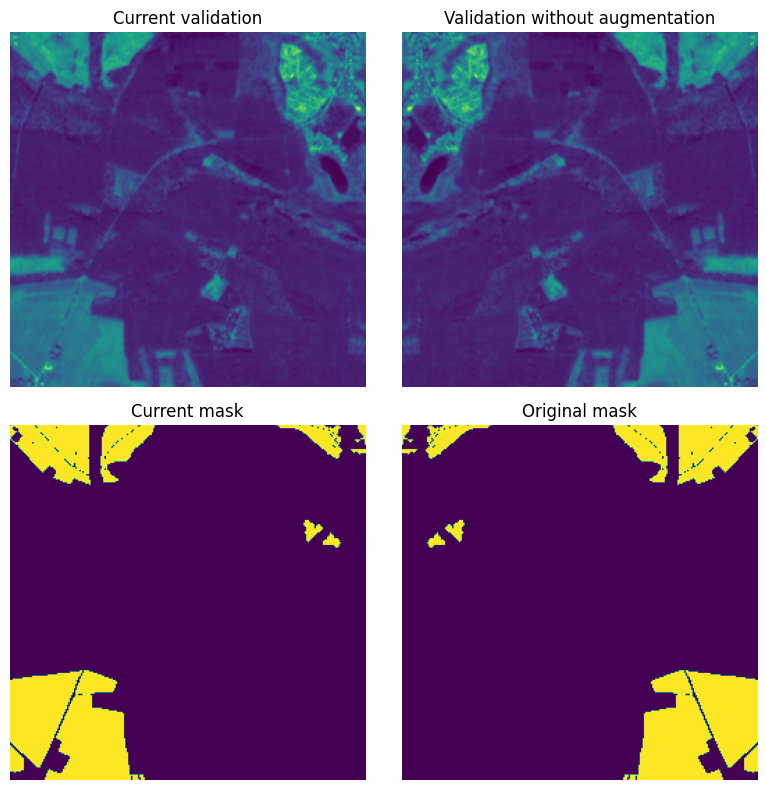


Repetition 2
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.0010538636
Mask difference: 0.0


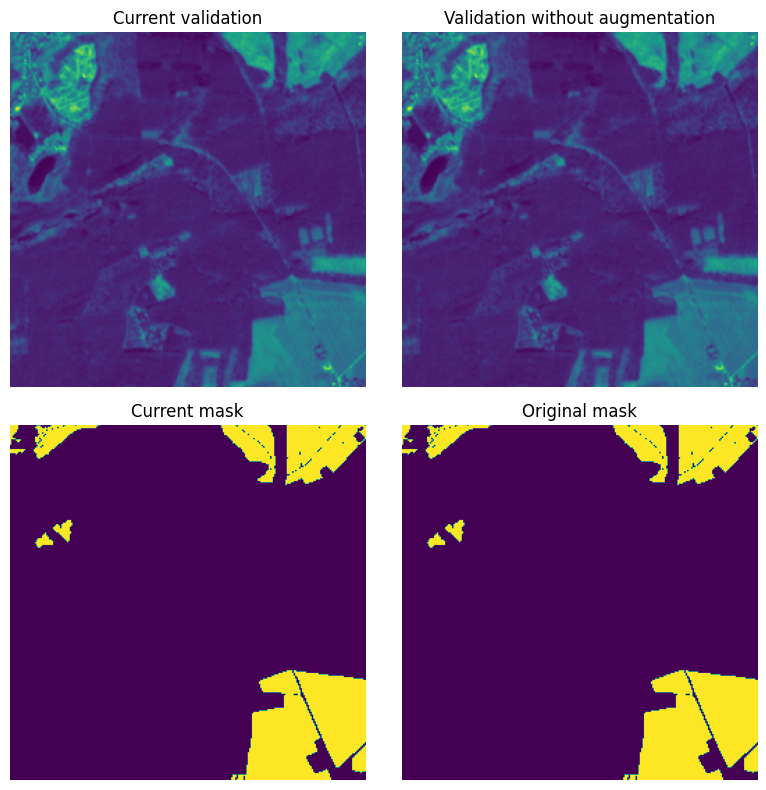


Repetition 3
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.46718815
Mask difference: 0.092648804


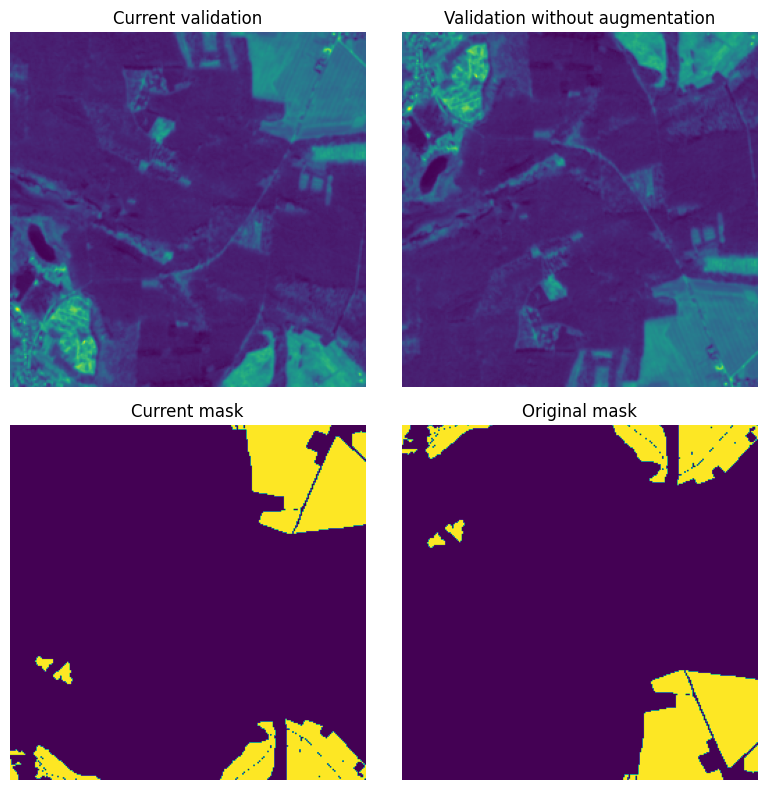


Repetition 4
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.5155373
Mask difference: 0.1255091


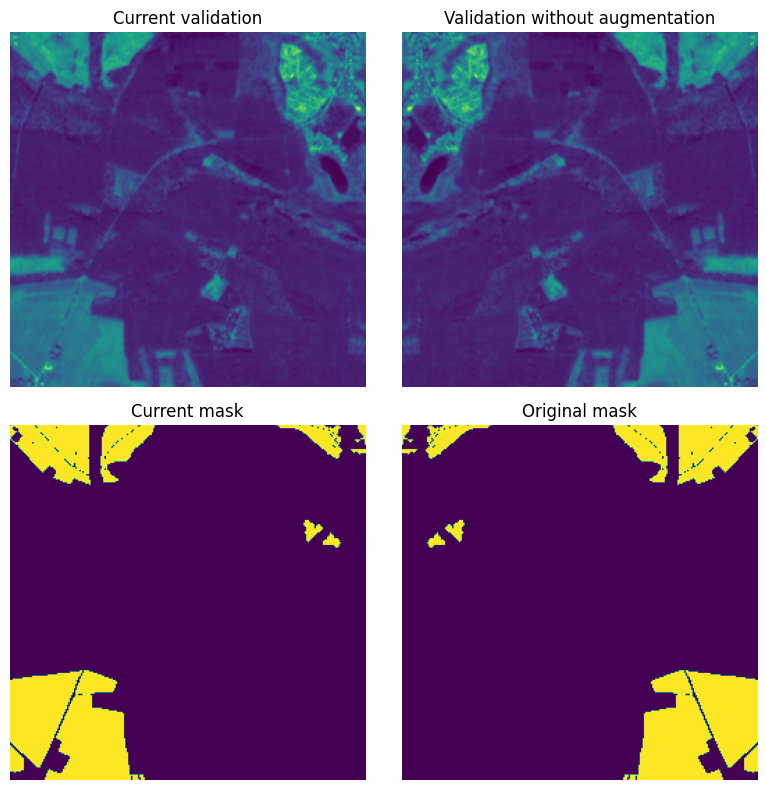


Repetition 5
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.36685562
Mask difference: 0.07510287


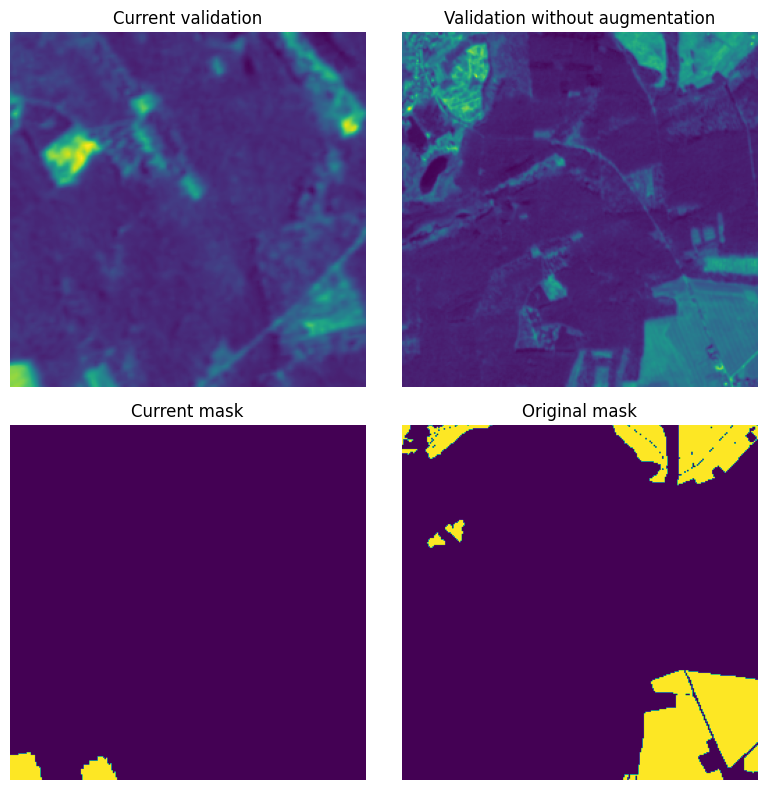


Repetition 6
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.5155373
Mask difference: 0.1255091


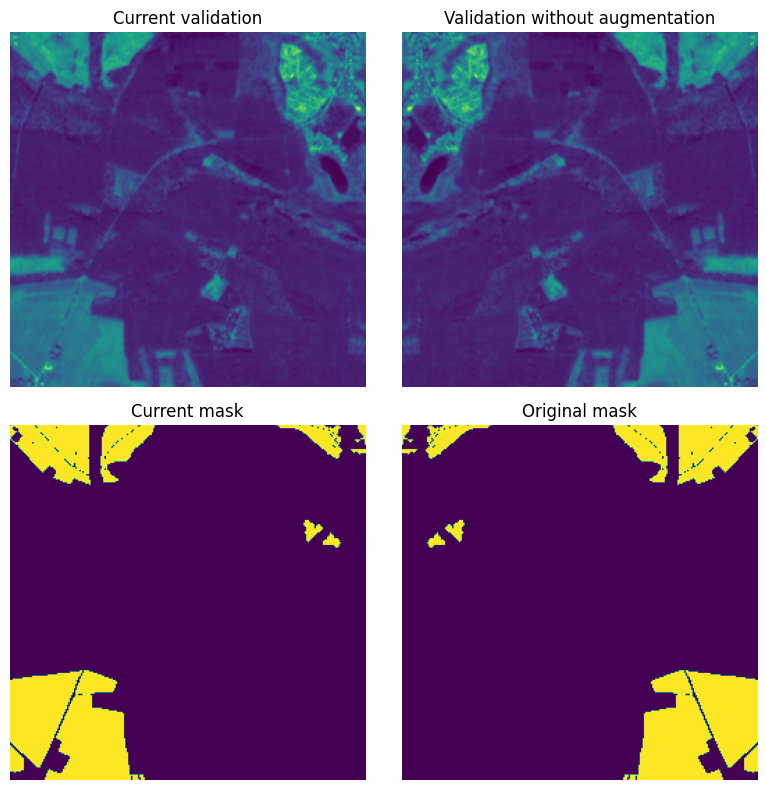


Repetition 7
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.3322583
Mask difference: 0.06910681


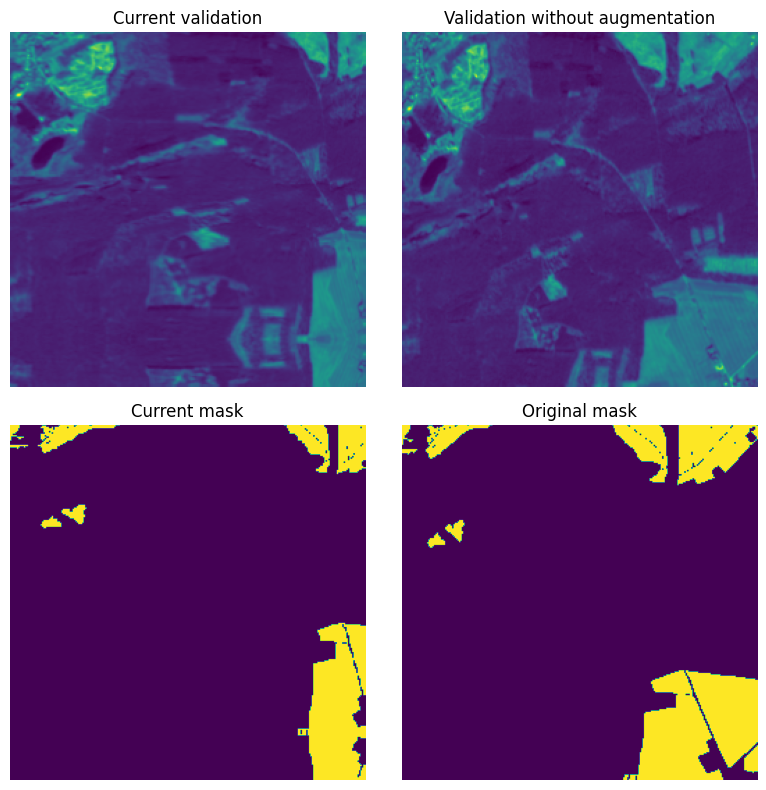


Repetition 8
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.0013679587
Mask difference: 0.0


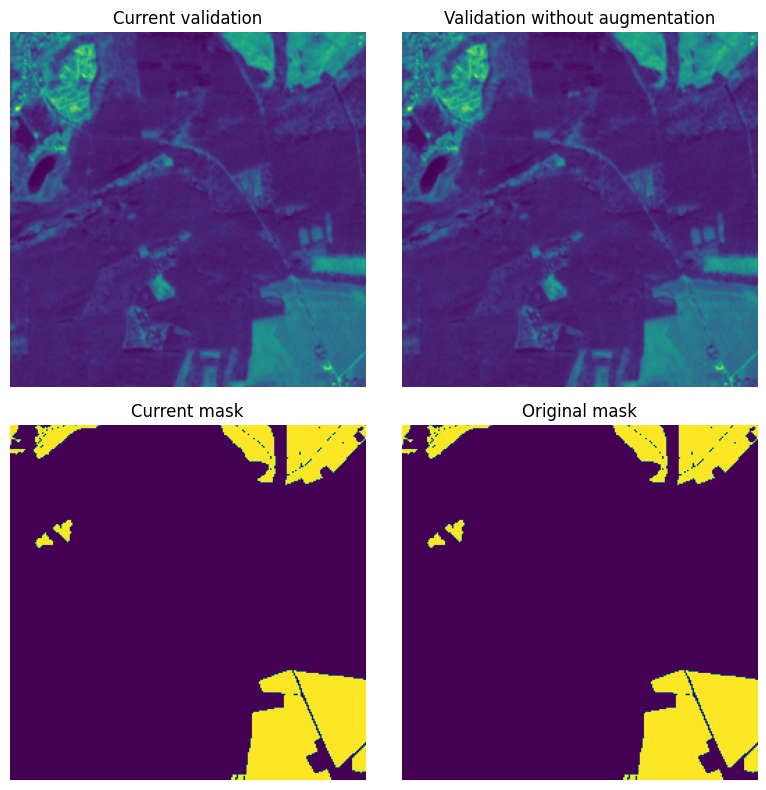


Repetition 9
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.28249452
Mask difference: 0.059574377


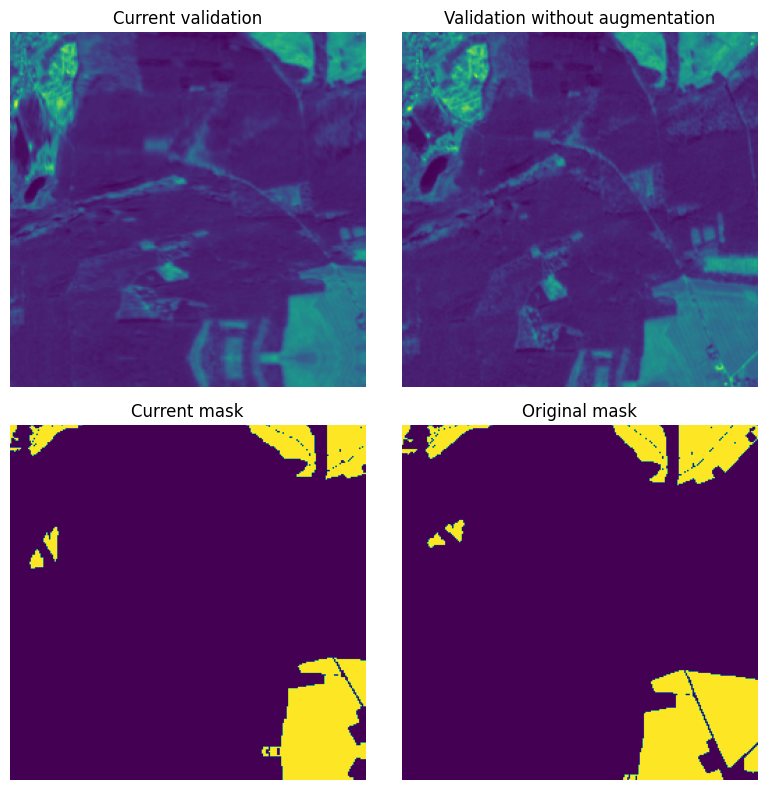


Repetition 10
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.0012371542
Mask difference: 0.0


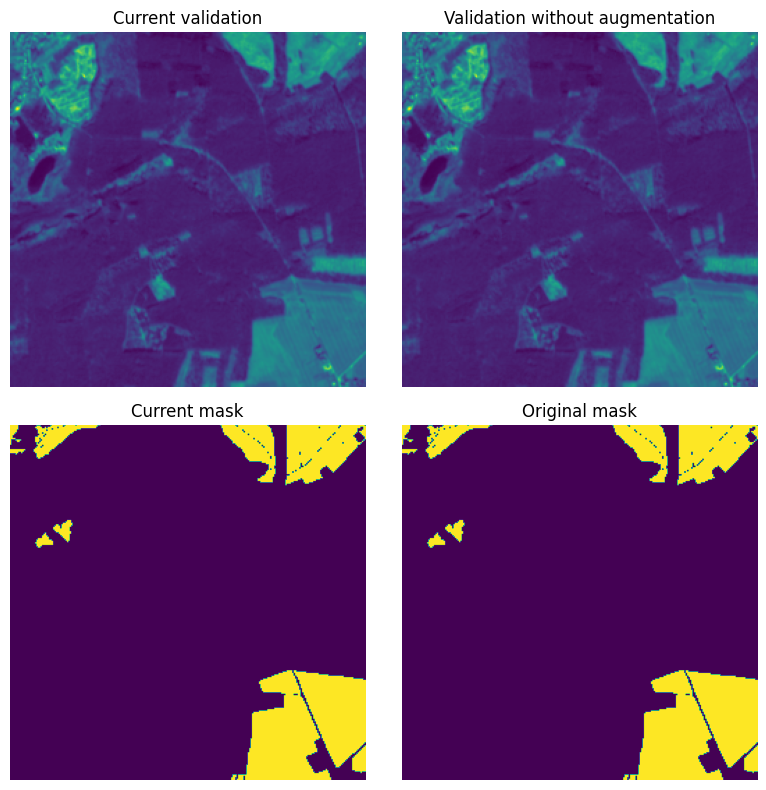


Repetition 11
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.38420066
Mask difference: 0.06965612


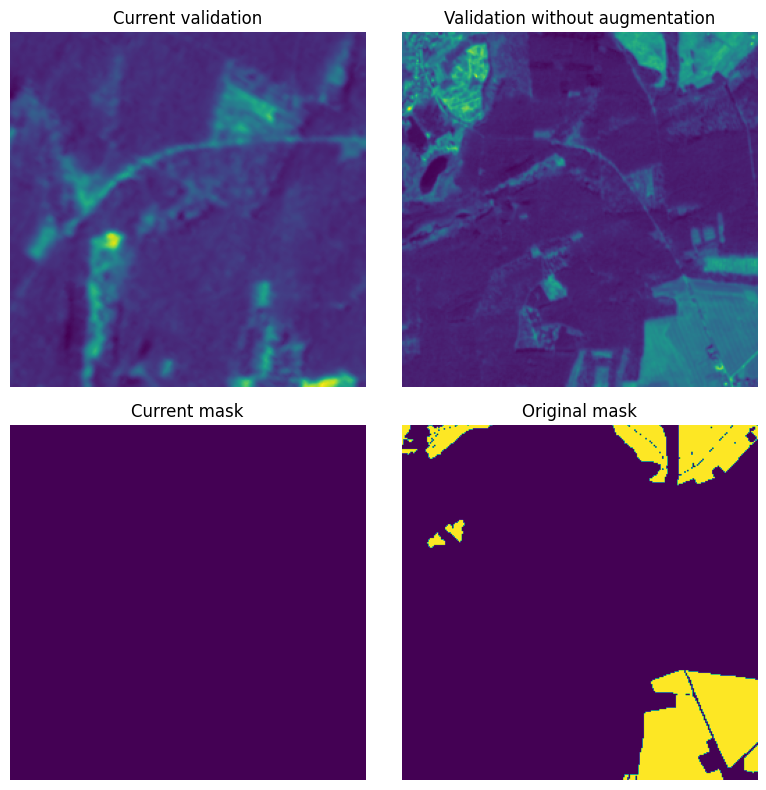


Repetition 12
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.5155373
Mask difference: 0.1255091


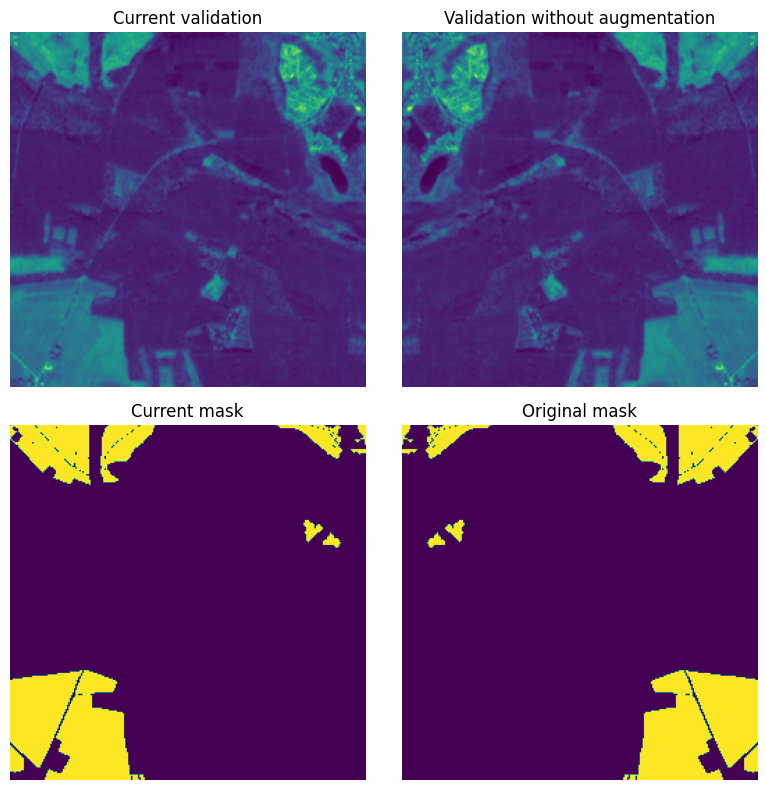


Repetition 13
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.40074697
Mask difference: 0.06965612


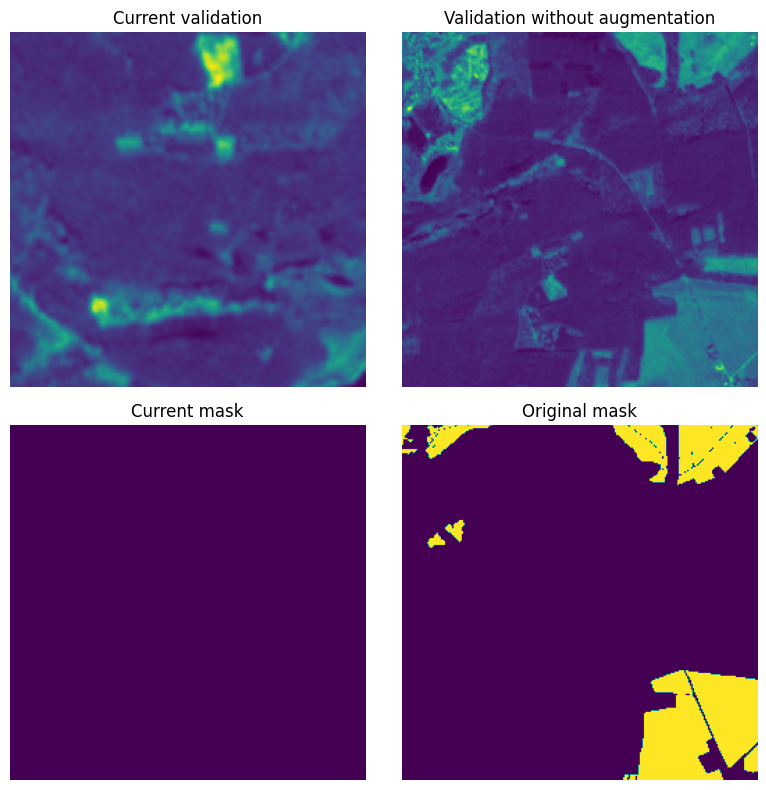


Repetition 14
current shape: (4, 6, 256, 256) (3, 256, 256)
no-aug shape:  (4, 6, 256, 256) (3, 256, 256)
Image difference: 0.39384615
Mask difference: 0.07811112


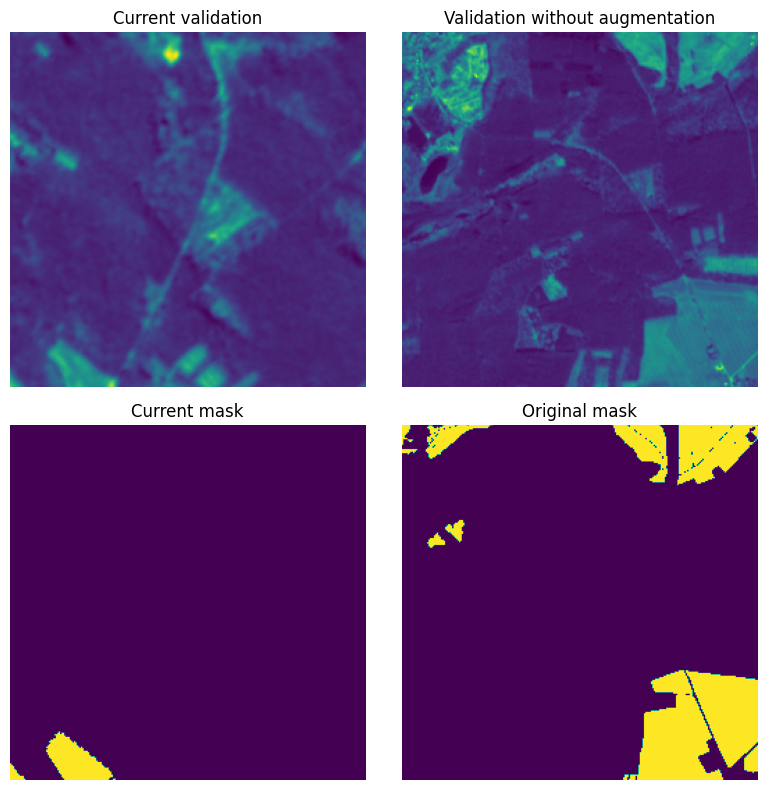

In [1]:
import sys

origin = '/workspace/'
sys.path.append('/media/')

from tqdm import tqdm
import pandas as pd
from datetime import datetime

from torch.utils.data import DataLoader
from FieldWaterUseTools.FuncBox.other_repos.tfcl.models.ptavit3d import ptavit3d_dn
from FieldWaterUseTools.FuncBox.other_repos.tfcl.nn.loss.ftnmt_loss import ftnmt_loss               
from FieldWaterUseTools.FuncBox.other_repos.tfcl.utils.classification_metric import Classification  
from FieldWaterUseTools.FuncBox.FieldFuncis import *
from FieldWaterUseTools.FuncBox.Misc import shuffle2Lists
import matplotlib.pyplot as plt

train_ds_path = f"{origin}fields/02_Chips_generated_from_IACS/Fine_dilate_True/"
imgs_list = getFilelist(train_ds_path, '.nc', deep=True)
masks_list = getFilelist(train_ds_path, '.tif', deep=True)

listOfimgs, listOfmasks = shuffle2Lists(imgs_list, masks_list)
train_valid_split = 0.75

# Current implementation
valid_dataset_current = AI4BDataset(
    list_of_imgs=listOfimgs,
    list_of__masks=listOfmasks,
    mode='valid',
    ntrain=train_valid_split
)

# Explicitly disable augmentation
valid_dataset_noaug = AI4BDataset(
    list_of_imgs=listOfimgs,
    list_of__masks=listOfmasks,
    transform=TrainingTransformS2(mode='valid'),
    mode='valid',
    ntrain=train_valid_split
)

idx = 0

# Get the same validation sample several times
for rep in range(15):
    img_current, mask_current = valid_dataset_current[idx]
    img_noaug, mask_noaug = valid_dataset_noaug[idx]

    print(f"\nRepetition {rep}")
    print("current shape:", img_current.shape, mask_current.shape)
    print("no-aug shape: ", img_noaug.shape, mask_noaug.shape)

    # If augmentation is occurring, repeated retrievals should differ
    print(
        "Image difference:",
        np.mean(np.abs(img_current - img_noaug))
    )

    print(
        "Mask difference:",
        np.mean(np.abs(mask_current - mask_noaug))
    )

    # Show one band/time step
    fig, ax = plt.subplots(2, 2, figsize=(8, 8))

    ax[0, 0].imshow(img_current[0, 0])
    ax[0, 0].set_title("Current validation")

    ax[0, 1].imshow(img_noaug[0, 0])
    ax[0, 1].set_title("Validation without augmentation")

    ax[1, 0].imshow(mask_current[0])
    ax[1, 0].set_title("Current mask")

    ax[1, 1].imshow(mask_noaug[0])
    ax[1, 1].set_title("Original mask")

    for a in ax.ravel():
        a.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import sys

origin = '/workspace/'
sys.path.append('/media/')

from tqdm import tqdm
from torch.amp import autocast, GradScaler
import pandas as pd
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from FieldWaterUseTools.FuncBox.other_repos.tfcl.models.ptavit3d import ptavit3d_dn
from FieldWaterUseTools.FuncBox.other_repos.tfcl.nn.loss.ftnmt_loss import ftnmt_loss               
from FieldWaterUseTools.FuncBox.other_repos.tfcl.utils.classification_metric import Classification  
from FieldWaterUseTools.FuncBox.FieldFuncis import *
from FieldWaterUseTools.FuncBox.Misc import shuffle2Lists


dilate = 'True'
overlap = 'with'
# set the rocksdb on which training will be performed
db_name = f"FromScratch_IACS_dilate_{dilate}_BW_BorderEdgeCutted_RGB_NDVI_exclude_True_{overlap}_overlap"
print(f'learn with {db_name}')

# create output dictionary
keys = ['Epoch', 'Iteration','Loss', 'Mode']
vals = [list() for _ in range(len(keys))]
res_loss  = dict(zip(keys, vals))

keys = ['Epoch', 'MCC']
vals = [list() for _ in range(len(keys))]
res_mcc  = dict(zip(keys, vals))

def train(args):
    # dummy variable to keep track of mcc
    conti = [1,2]
    mcc_dum = 0
    num_epochs = args.epochs
    batch_size = args.batch_size

    torch.manual_seed(0)
    local_rank = 0
    # torch.cuda.set_device(local_rank)
    torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    NClasses = 1
    nf = 96
    verbose = True
    model_config = {'in_channels': 4,
                    'spatial_size_init': (128, 128),
                    'depths': [2, 2, 5, 2],
                    'nfilters_init': nf,
                    'nheads_start': nf // 4,
                    'NClasses': NClasses,
                    'verbose': verbose,
                    'segm_act': 'sigmoid'}

    model = ptavit3d_dn(**model_config).to(local_rank)
    criterion = ftnmt_loss()
    criterionV = ftnmt_loss()
    criterion_features = ftnmt_loss(axis=[-3, -2, -1])
    optimizer = torch.optim.RAdam(model.parameters(), lr=1e-3, eps=1.e-6)
    scaler = GradScaler()

    train_valid_split = 0.75
    train_ds_path = f"{origin}fields/02_Chips_generated_from_IACS/Fine_dilate_{dilate}_BW/"
    imgs_list = getFilelist(train_ds_path, '.nc', deep=True)
    masks_list = getFilelist(train_ds_path, '.tif', deep=True)

    listOfimgs, listOfmasks = shuffle2Lists(imgs_list, masks_list)

    train_dataset = AI4BPatchDataset(list_of_imgs=listOfimgs,list_of__masks=listOfmasks, patch_size=128, stride=64,
                                     transform=TrainingTransformS2(), mode='train', ntrain=train_valid_split)
    # train_dataset = AI4BPatchDataset(path_to_data=f"{origin}fields/Fine_tune_dilate_True/", patch_size=128, stride=64, mode='train')
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=3, pin_memory=True)

    valid_dataset = AI4BDataset(list_of_imgs=listOfimgs,list_of__masks=listOfmasks, mode='valid', ntrain=train_valid_split)
    # valid_dataset = AI4BPatchDataset(path_to_data=f"{origin}fields/Fine_tune_dilate_True/", patch_size=128, stride=64, mode='valid')
    valid_loader = DataLoader(dataset=valid_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=3, pin_memory=True)

    print(len(train_dataset))
    print(len(valid_dataset))

    start = datetime.now()
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs", position=0)


    for epoch in epoch_pbar:
        tot_loss = 0
        model.train() # train function from ptavit3d_dn(torch.nn.Module) is called
        train_pbar = tqdm(train_loader, desc=f"Training Epoch {epoch}", position=1, leave=False)
        for i, data in enumerate(train_pbar):

            images, labels = data
            images = images.to(local_rank, non_blocking=True)
            labels = labels.to(local_rank, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda', dtype=torch.bfloat16):
                preds_target = model(images)
                loss = mtsk_loss(preds_target, labels, criterion, NClasses)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tot_loss += loss.item()
            train_pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

               # for export
            res_loss['Epoch'].append(epoch)
            res_loss['Iteration'].append(i)
            res_loss['Loss'].append(loss.item())
            res_loss['Mode'].append('Train')

        kwargs = monitor_epoch(model, epoch, valid_loader, res=res_loss, criterion=criterionV, NClasses=NClasses)
        kwargs['tot_train_loss'] = tot_loss
        # for export
        res_mcc['Epoch'].append(epoch)
        res_mcc['MCC'].append(kwargs['mcc'])

        # check if mcc higher than ever observed
        if kwargs['mcc'] > mcc_dum:
            mcc_dum = kwargs['mcc']
            conti[0] = model.state_dict()
            conti[1] = epoch
        
     
        #res.append 
        if verbose:
            output_str = ', '.join(f'{k}:: {v}, |===|, ' for k, v in kwargs.items())
            epoch_pbar.write(output_str)


    if verbose:
        print("Training completed in: " + str(datetime.now() - start))

    
    torch.save(conti[0], f'{origin}fields/03_Output/models/model_state_{db_name}_{conti[1]}_CONTROL.pth') # 

    df  = pd.DataFrame(data = res_loss)
    df.to_csv(f'{origin}fields/03_Output/loss/loss_{db_name}_{conti[1]}.csv', sep=',',index=False)

    df  = pd.DataFrame(data = res_mcc)
    df.to_csv(f'{origin}fields/03_Output/loss/MCC_{db_name}_{conti[1]}.csv', sep=',',index=False)


def main():
    class Args:
        def __init__(self):
            self.epochs = 50
            self.batch_size = 3 # H100 test - 94GB GPU memory

    args = Args()
        
    train(args)

if __name__ == '__main__':
    main()